# Task 1: Exploring and Visualizing the Iris Dataset

---

## Introduction & Problem Statement

This notebook focuses on **Exploratory Data Analysis (EDA)** of the classic **Iris Dataset** using Python.

The goal is to:
- Load and understand the dataset structure
- Summarize key statistics
- Create meaningful visualizations (scatter plots, histograms, box plots)
- Draw insights about the relationships between features and species

**Libraries used:** `pandas`, `matplotlib`, `seaborn`

---

## Step 1: Import Required Libraries

In [1]:
# ─── Import all necessary libraries ───────────────────────────────────────────
import pandas as pd                  # Data loading and manipulation
import matplotlib.pyplot as plt      # Base plotting library
import seaborn as sns                # Statistical visualization (built on matplotlib)
import warnings

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')

# Set a consistent visual style for all plots
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.2)
plt.rcParams['figure.dpi'] = 120     # Higher resolution figures

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Step 2: Load the Dataset

We load the Iris dataset from the provided CSV file using `pandas.read_csv()`.

In [2]:
# ─── Load the dataset from CSV ────────────────────────────────────────────────
df = pd.read_csv('Iris.csv')

print("Dataset loaded successfully!")
print(f"   Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")

Dataset loaded successfully!
   Rows: 150  |  Columns: 6


---
## Step 3: Dataset Understanding & Description

We inspect the structure, columns, data types, and first few rows to understand what we are working with.

In [3]:
# ─── Display dataset shape (rows × columns) ───────────────────────────────────
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 6)


In [4]:
# ─── Display column names ─────────────────────────────────────────────────────
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [5]:
# ─── Preview the first 5 rows of the dataset ──────────────────────────────────
print("First 5 Rows (df.head()):")
df.head()

First 5 Rows (df.head()):


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# ─── Check data types and non-null counts for each column ─────────────────────
print("Dataset Info (data types and nulls):")
df.info()

Dataset Info (data types and nulls):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
# ─── Statistical summary of numerical columns ─────────────────────────────────
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


In [8]:
# ─── Count records per species ────────────────────────────────────────────────
print("Species Distribution:")
print(df['Species'].value_counts())

Species Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


---
## Step 4: Data Summarization

Before visualization, we check for:
- Missing values
- Duplicate rows
- Irrelevant columns
- Correct data types

In [18]:
# ─── Check for missing (null) values in each column ───────────────────────────
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values per Column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total missing values: 0


In [19]:
# ─── Check for duplicate rows ─────────────────────────────────────────────────
duplicates = df.duplicated().sum()
print(f"Duplicate Rows Found: {duplicates}")

# Remove duplicates if any exist
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"   Removed {duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("   No duplicates found. Dataset is clean!")

Duplicate Rows Found: 0
   No duplicates found. Dataset is clean!


In [20]:
# ─── Drop the 'Id' column, it's just a row index, not a feature ──────────────
df = df.drop(columns=['Id'])
print("  'Id' column dropped. Remaining columns:", df.columns.tolist())

  'Id' column dropped. Remaining columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [21]:
# ─── Clean up species names: remove 'Iris-' prefix for cleaner labels ──────────
df['Species'] = df['Species'].str.replace('Iris-', '', regex=False)
print("Species labels cleaned:")
print(df['Species'].unique())
# Preview the cleaned dataset
df.head()

Species labels cleaned:
['setosa' 'versicolor' 'virginica']


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---
## Step 5: Exploratory Data Analysis (EDA) with Graphs

I create **4 types of visualizations** to understand the data:
1. **Scatter Plot** relationships between features
2. **Histogram** distribution of each feature
3. **Box Plot** outliers and spread
4. **Pair Plot** *(bonus)* all feature combinations at once

### 5.1 Scatter Plot: Sepal Length vs Sepal Width

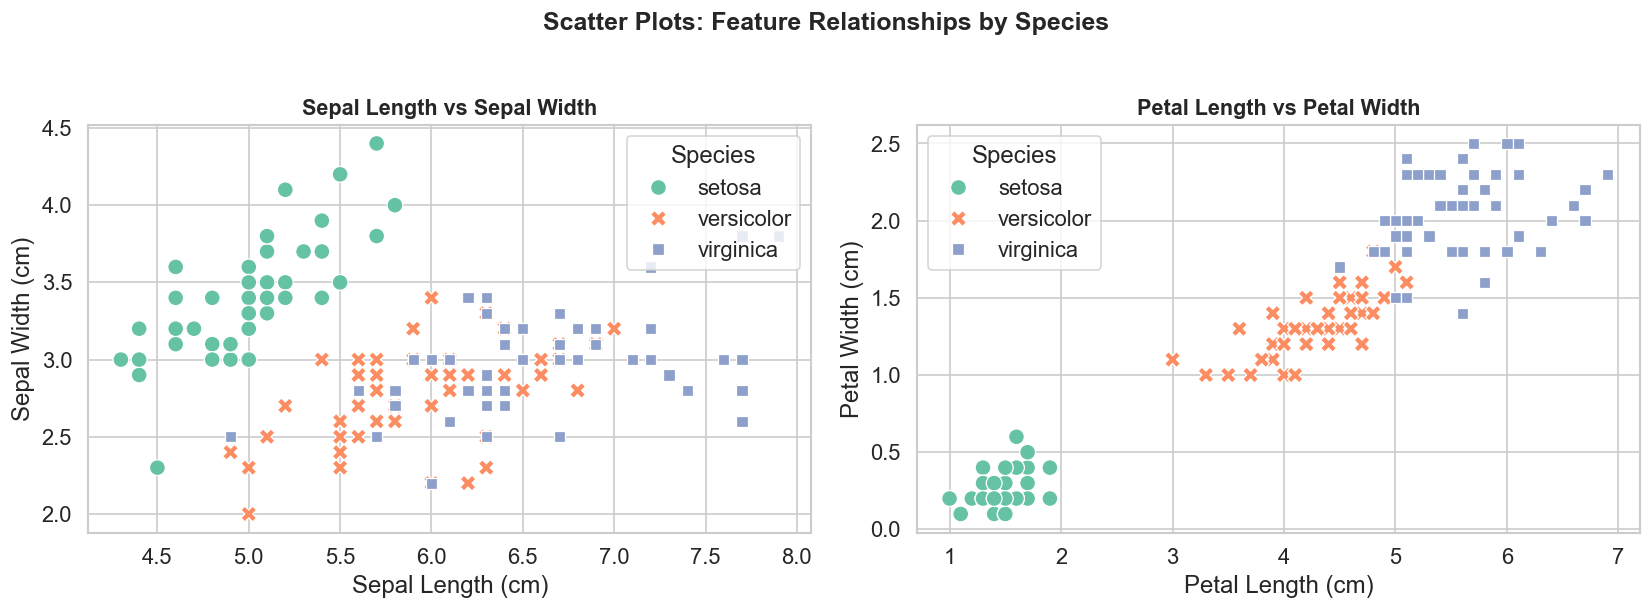

💡 Insight: Petal features separate the three species much more clearly than sepal features.


In [22]:
# ─── Scatter Plot: Sepal Length vs Sepal Width, colored by Species ────────────
# This reveals how well sepal measurements separate the three species

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Sepal Length vs Sepal Width ---
sns.scatterplot(
    data=df,
    x='SepalLengthCm',
    y='SepalWidthCm',
    hue='Species',            # Color points by species
    style='Species',          # Different marker shapes per species
    s=90,                     # Marker size
    ax=axes[0]
)
axes[0].set_title('Sepal Length vs Sepal Width', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')

# --- Plot 2: Petal Length vs Petal Width ---
sns.scatterplot(
    data=df,
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species',
    style='Species',
    s=90,
    ax=axes[1]
)
axes[1].set_title('Petal Length vs Petal Width', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')

plt.suptitle('Scatter Plots: Feature Relationships by Species',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_plots.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Petal features separate the three species much more clearly than sepal features.")

### 5.2 Histogram: Distribution of Each Feature

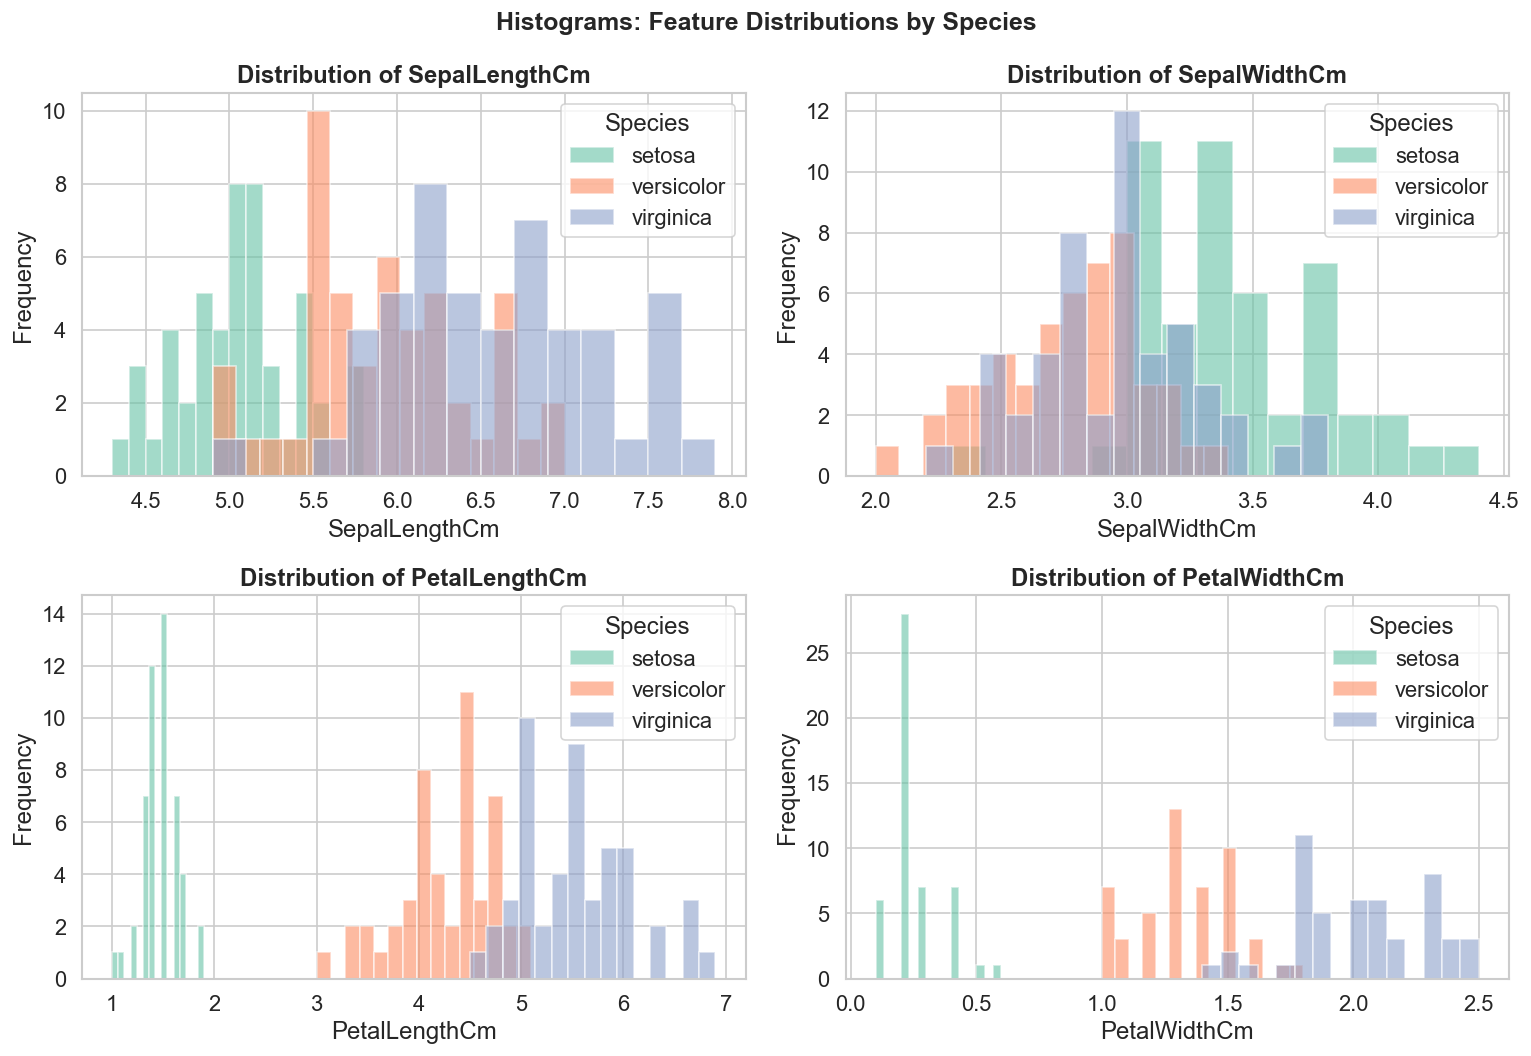

💡 Insight: Petal measurements show clear, non-overlapping distributions ideal for classification.


In [23]:
# ─── Histograms: distribution of all 4 numeric features per species ────────────
# Overlapping histograms show how species differ across each measurement

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()   # Flatten 2×2 grid into a 1D list for easy iteration

for i, feature in enumerate(features):
    for species in df['Species'].unique():
        # Plot a separate histogram for each species on the same axis
        axes[i].hist(
            df[df['Species'] == species][feature],
            bins=15,
            alpha=0.6,          # Transparency so overlapping bars are visible
            label=species,
            edgecolor='white'
        )
    axes[i].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(title='Species')

plt.suptitle('Histograms: Feature Distributions by Species',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('histograms.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Petal measurements show clear, non-overlapping distributions ideal for classification.")

### 5.3 Box Plot: Outliers and Spread of Values

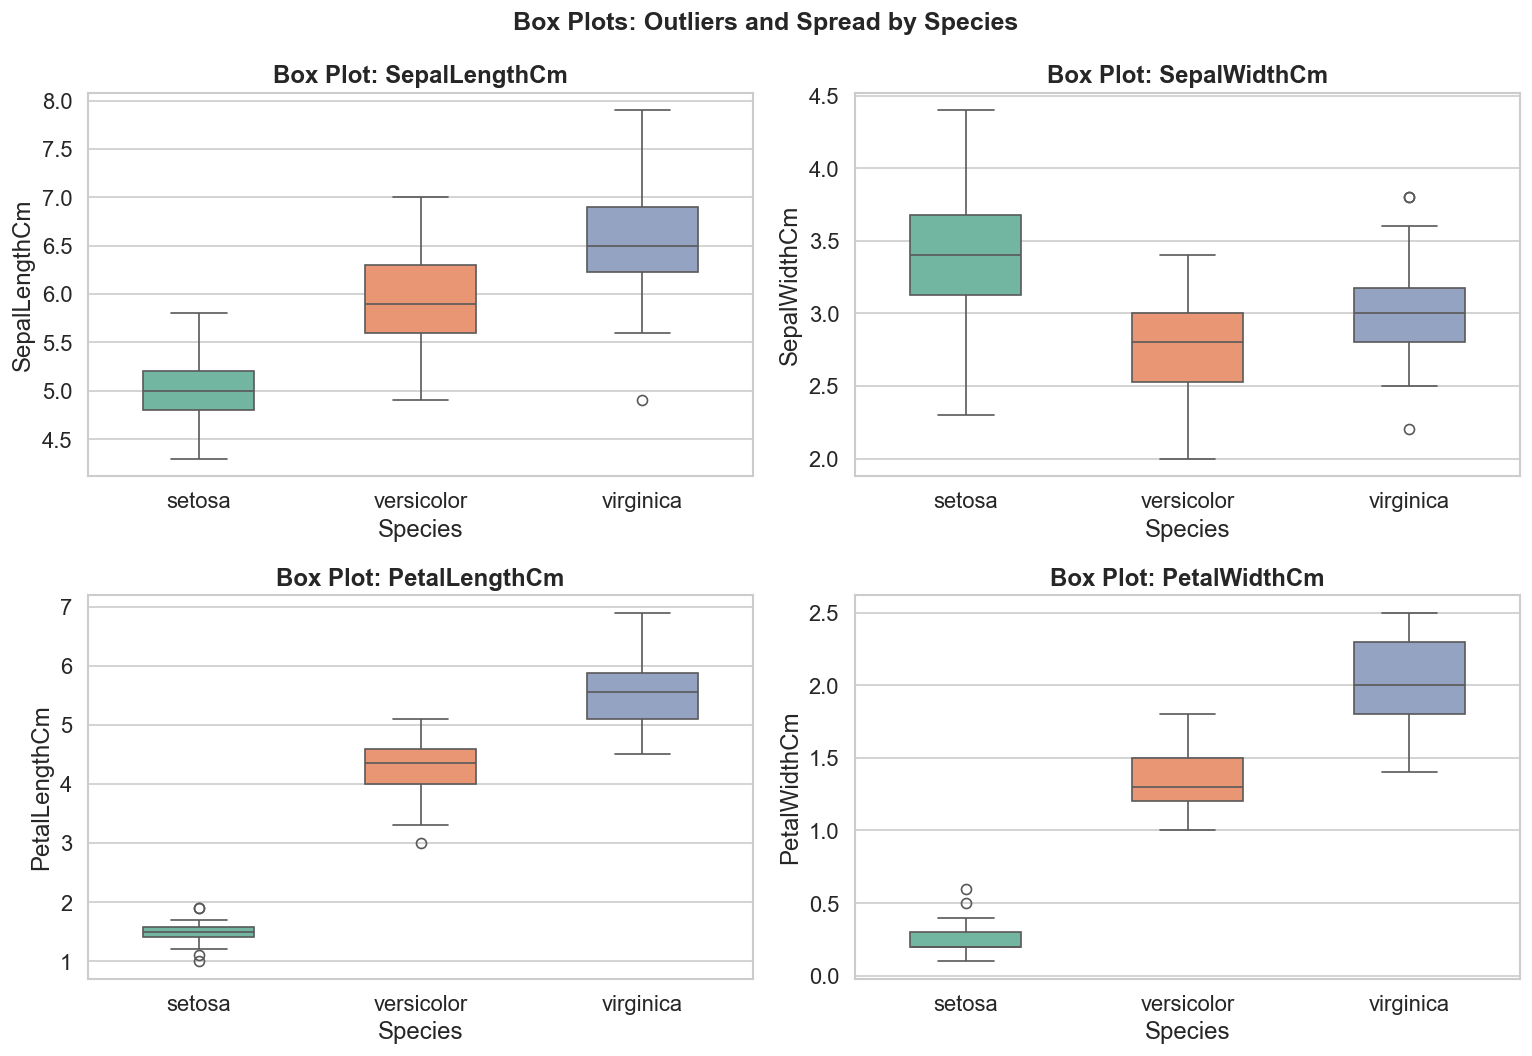

💡 Insight: Virginica has the largest petals on average. Setosa shows a few outliers in SepalWidthCm.


In [24]:
# ─── Box Plots: spread, median, and outliers for each feature by species ───────
# Box plots show: median (line), IQR (box), whiskers (range), and outliers (dots)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='Species',
        y=feature,
        hue='Species',          # Color by species
        palette='Set2',
        width=0.5,
        flierprops=dict(marker='o', color='red', markersize=6),  # Outlier style
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f'Box Plot: {feature}', fontweight='bold')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(feature)

plt.suptitle('Box Plots: Outliers and Spread by Species',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Virginica has the largest petals on average. Setosa shows a few outliers in SepalWidthCm.")

In [13]:
### 5.4 Bonus: Pair Plot: All Feature Combinations

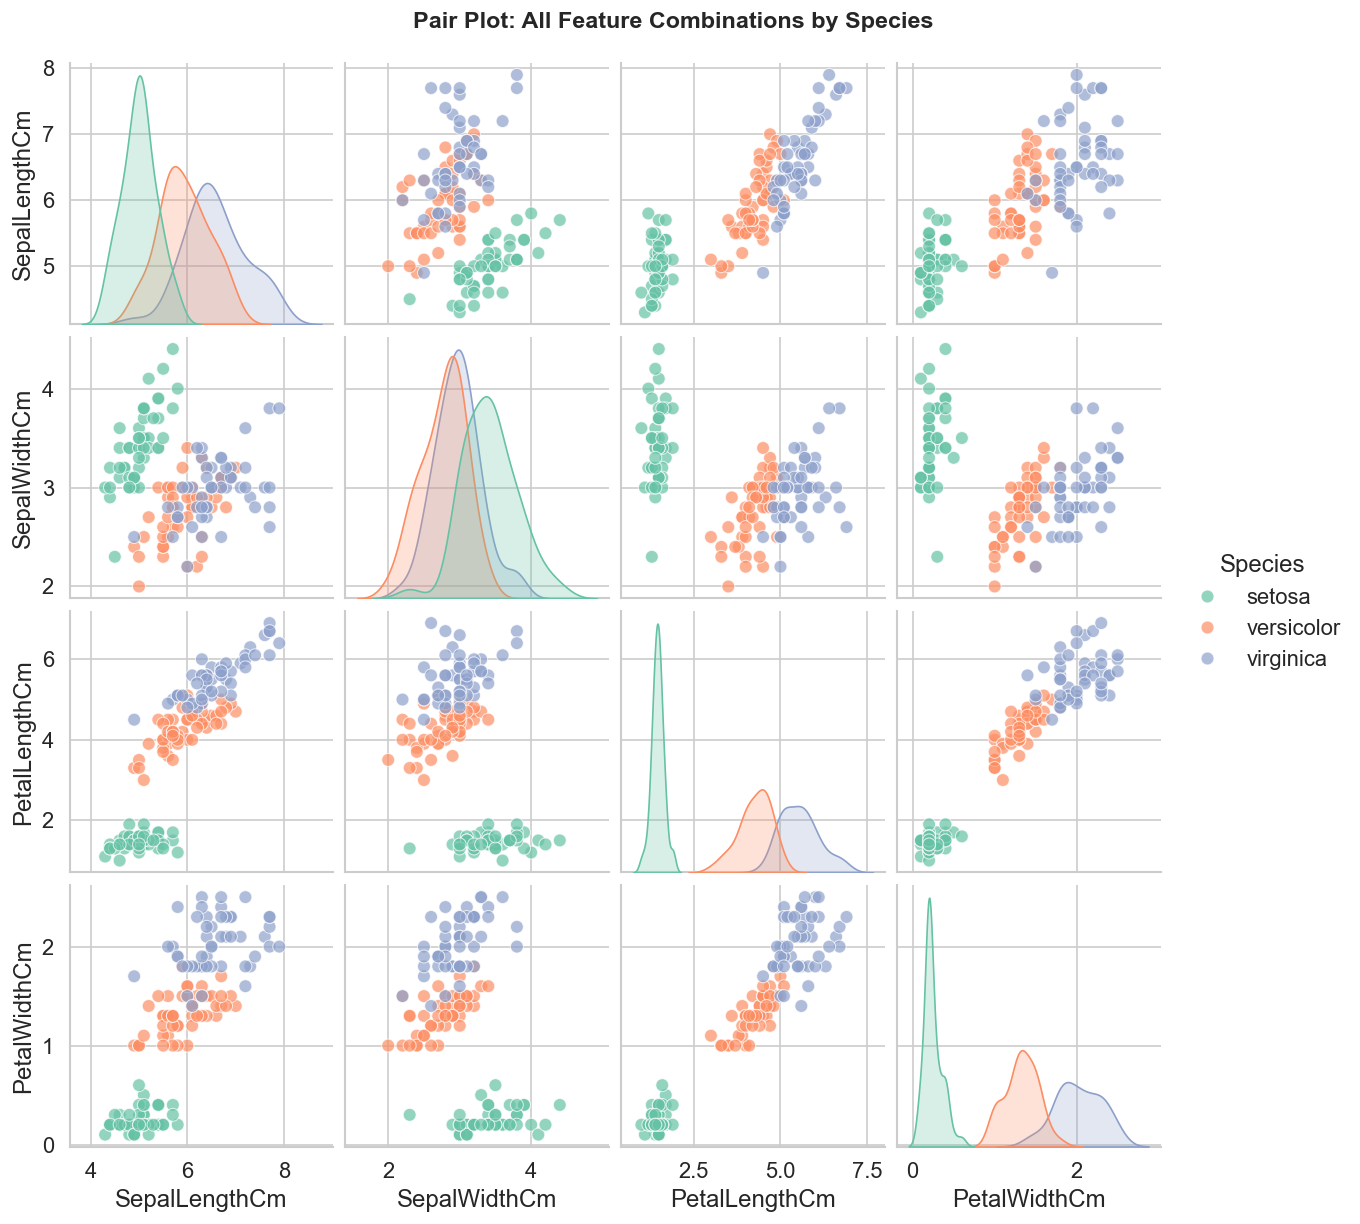

💡 Insight: PetalLengthCm × PetalWidthCm gives the best visual separation of all three species.


In [25]:
# ─── Pair Plot: every feature vs every other feature, colored by species ───────
# The diagonal shows KDE (distribution) plots; off-diagonal shows scatter plots
# This is the fastest way to get an overview of all feature relationships

pair_plot = sns.pairplot(
    df,
    hue='Species',          # Color by species
    diag_kind='kde',        # Kernel Density Estimate on the diagonal
    plot_kws={'alpha': 0.7, 's': 60},
    palette='Set2'
)
pair_plot.fig.suptitle('Pair Plot: All Feature Combinations by Species',
                        y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()
print("💡 Insight: PetalLengthCm × PetalWidthCm gives the best visual separation of all three species.")

### 5.5 Bonus: Correlation Heatmap

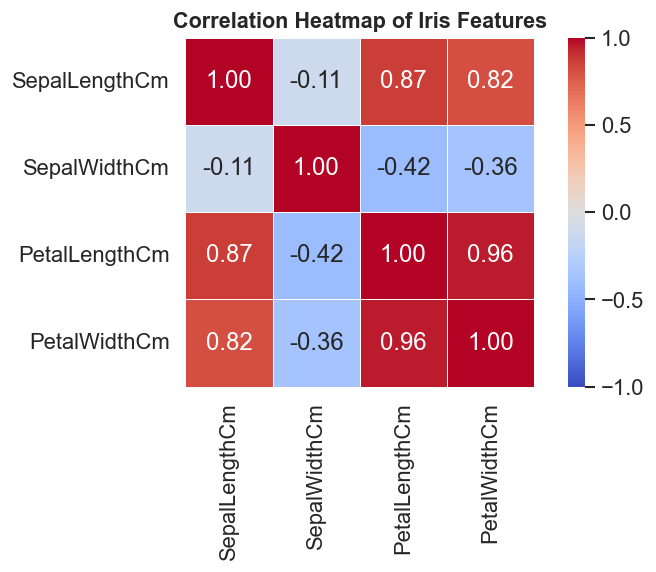

💡 Insight: Petal Length and Petal Width are highly correlated (0.96), they carry similar information.


In [26]:
# ─── Correlation Heatmap: how strongly each numeric feature relates to others ──
# Values close to +1 = strong positive correlation; close to -1 = strong negative

plt.figure(figsize=(7, 5))

# Compute the Pearson correlation matrix for numeric columns only
corr_matrix = df[features].corr().round(2)

sns.heatmap(
    corr_matrix,
    annot=True,             # Show correlation values inside each cell
    fmt='.2f',
    cmap='coolwarm',        # Red = high positive, Blue = high negative
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap of Iris Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Petal Length and Petal Width are highly correlated (0.96), they carry similar information.")

---
## Step 6: Conclusion: Key Insights

After loading, cleaning, and visualizing the Iris dataset, here are the **key findings**:

| Insight | Detail |
|---|---|
| **Dataset** | 150 samples × 5 features (4 numeric + 1 categorical); perfectly balanced, 50 samples per species |
| **No missing data** | The dataset is clean, no null values or duplicates were found |
| **Best separating features** | `PetalLengthCm` and `PetalWidthCm` clearly separate all three species |
| **Weakest separator** | `SepalWidthCm` shows significant overlap between species |
| **Setosa is easiest** | *Iris setosa* is completely separated from the other two species in petal measurements |
| **Versicolor & Virginica overlap** | These two are harder to distinguish, especially using sepal features |
| **High correlation** | Petal Length and Petal Width are ~96% correlated, they are redundant features |
| **Outliers** | A few outliers exist in `SepalWidthCm` for *setosa*, but they do not affect overall patterns |

### Skills Demonstrated
- ✅ Data loading and inspection using **pandas** (`.shape`, `.columns`, `.head()`, `.describe()`, `.info()`)
- ✅ Basic data summarization (missing value check, duplicate detection, value counts)
- ✅ Visualization using **matplotlib** and **seaborn** (scatter, histogram, box plot, pair plot, heatmap)
